## 1. Load Lab5a

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
path = "/content/drive/MyDrive/Colab Notebooks/Lab5a_GNN_SMILES_processing_2026.ipynb"

%run "$path"

Mounted at /content/drive
[['cmpdname', 'mf', 'isosmiles', 'xlogp'], ['1-Aminopropan-2-ol', 'C3H9NO', 'CC(CN)O', '-1'], ['"1-Chloro-2,4-dinitrobenzene"', 'C6H3ClN2O4', 'C1=CC(=C(C=C1[N+](=O)[O-])[N+](=O)[O-])Cl', '2.3'], ['9-Ethyladenine', 'C7H9N5', 'CCN1C=NC2=C(N=CN=C21)N', '0.2'], ['"1,2-Dichloroethane"', 'C2H4Cl2', 'C(CCl)Cl', '1.5']]
266712
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 25.3 MB/s eta 0:00:00
[0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 1 0 0 0]
[0 1 0 0 0]
Molecule     : 1-Aminopropan-2-ol | CC(CN)O
Num atoms    : 14

elements     : (14, 33)
hybridization: (14, 8)
chirality    : (14, 5)
aromatic     : (14, 1)
charge       : (14, 1)

final atoms  : (14, 48)
Processing 999 molecules using 2 CPU cores...


Processing molecules: 100%|██████████| 999/999 [00:01<00:00, 823.13it/s]


Successfully processed: 965 molecules
C2H3ClO
tf.Tensor(
[[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
  0 0 0 0 0 1 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
  0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
  0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
  0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 1 0 1 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 1 0 1 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 1 0 1 0 0 0 0 0 0]], shape=(7, 48), dtype=int32)
tf.Tensor(
[[1 0 0 0 0 0]
 [0 1 0 0 0 0]
 [1 0 0 0 0 0]
 [1 0 0 0 0 0]
 [1 0 0 0 0 0]
 [1 0 0 0 0 0]], shape=(6, 6), dtype=int32)
tf.Tensor(
[[0 1 0 0 0 1]
 [1 2 3 4 5 6]], shape=(2, 6), dtype=int32)
Total 

## 2. Message Passing NN layer implementation

For each bond in the molecule, the layer combines the source atom's features with the bond's features to generate a message.

All incoming messages are then summed at each target atom and passed through an MLP to produce updated atom representations that now encode information about the local chemical environment.

In [ ]:
import tensorflow as tf

def edge_enhanced_gnn_layer(node_features, edge_index, edge_features,
                            node_mlp_weights, message_mlp_weights):
    """
    Pure function implementing the MPNN layer with edge features.

    Args:
        node_features: Tensor of shape (N, node_feat_dim); N = number of nodes
        edge_index: Tensor of shape (2, M); M = number of edges
        edge_features: Tensor of shape (M, edge_feat_dim)
        node_mlp_weights: a Dense layer or weights for node update
        message_mlp_weights: a Dense layer or weights for message generation

    Returns:
        Updated node features: Tensor of shape (N, output_dim)
    """
    source = edge_index[0]  # (M,) edges from
    target = edge_index[1]  # (M,) edges to

    source_features = tf.gather(node_features, source)  # (M, node_feat_dim)
    message_inputs = tf.concat([source_features, edge_features], axis=-1)  # (M, node_feat_dim + edge_feat_dim)

    # Apply message MLP
    messages = message_mlp_weights(message_inputs)  # transforms (M, gnn_input_dim) to (M, hidden_dim); network size is gnn_input_dim x hidden_dim

    # Aggregate messages for each target node
    N = tf.shape(node_features)[0]
    hidden_dim = messages.shape[-1]
    aggregated = tf.zeros((N, hidden_dim), dtype=messages.dtype)

    # sum up transformed messages arriving at every node using the 'target' indexes
    # Input tensor to be processed is (M, hidden_dim); given indexing tensor (M,1)
    # with elements [0, N) we get (N, hidden_dim)
    aggregated = tf.tensor_scatter_nd_add(
        aggregated,
        tf.expand_dims(target, axis=1),  # (M, 1)
        messages
    )  # (N, hidden_dim)

    # Apply node update MLP
    updated_nodes = node_mlp_weights(aggregated)  # (N, hidden_dim)

    return updated_nodes


## 3. Verify data shapes

In [ ]:
print(V_train[0].shape)
print(E_i_train[0].shape)
print(E_f_train[0].shape)

(15, 48)
(2, 15)
(15, 6)


## 4. Define MLPs and forward pass

In [ ]:
# Dimensions
node_dim = V_train[0].shape[1]        # The number of features for an atom
edge_dim = E_f_train[0].shape[1]      # The number of features for a bond
gnn_input_dim = node_dim + edge_dim
gnn_hidden_dim = 64
hidden_layer_dim = 32

# Create MLPs
message_mlp = tf.keras.layers.Dense(gnn_hidden_dim, activation='relu', input_shape=(gnn_input_dim,))
node_mlp = tf.keras.layers.Dense(gnn_hidden_dim, activation='relu')
hidden_layer = tf.keras.layers.Dense(hidden_layer_dim, activation='relu')
output_layer = tf.keras.layers.Dense(1, activation=None)  # Predicting a real number

# Define the full forward function
def forward_pass(node_features, edge_index, edge_features,
                 message_mlp, node_mlp, hidden_layer, output_layer):
    """
    Full forward pass through the GNN + hidden layer + output layer.
    """
    # 1. GNN layer
    updated_nodes = edge_enhanced_gnn_layer(node_features, edge_index, edge_features,
                                            node_mlp, message_mlp)

    # 2. Global pooling (average pooling across all nodes)
    graph_embedding = tf.reduce_mean(updated_nodes, axis=0)  # (hidden_dim,)

    # 3. Hidden dense layer
    hidden = hidden_layer(tf.expand_dims(graph_embedding, axis=0))  # (1, hidden_dim_2)

    # 4. Output layer
    output = output_layer(hidden)  # (1, 1)

    return tf.squeeze(output, axis=0)  # Return scalar

# One layer call as a test
updated_nodes = edge_enhanced_gnn_layer(V_train[0], E_i_train[0], E_f_train[0], node_mlp, message_mlp)

print(updated_nodes.shape)  # (10, 64)

val = forward_pass(V_train[0], E_i_train[0], E_f_train[0], message_mlp, node_mlp, hidden_layer, output_layer)
print(val)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


(15, 64)
tf.Tensor([0.06581604], shape=(1,), dtype=float32)


## 5. Training loop

In [ ]:
num_graphs = len(V_train)
epochs = 50
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
loss_fn = tf.keras.losses.MeanSquaredError()

# Containers for tracking metrics
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(epochs):
    total_loss = 0.0
    total_accuracy = 0.0

    # --- Training loop over all molecular graphs in the training set ---
    for node_features, edge_index, edge_features, target, name, formula in zip(V_train, E_i_train, E_f_train, Y_train, names_train, formulas_train):
        with tf.GradientTape() as tape:
            try:
                prediction = forward_pass(node_features, edge_index, edge_features,
                                          message_mlp, node_mlp, hidden_layer, output_layer)
            except:
                print(name, formula, node_features.shape)
                break

            loss = loss_fn(target, prediction)

        # Update model weights
        trainable_vars = (message_mlp.trainable_variables +
                          node_mlp.trainable_variables +
                          hidden_layer.trainable_variables +
                          output_layer.trainable_variables)
        gradients = tape.gradient(loss, trainable_vars)
        optimizer.apply_gradients(zip(gradients, trainable_vars))

        total_loss += loss.numpy()
        total_accuracy += tf.reduce_mean(tf.abs(target - prediction))

    avg_train_loss = total_loss / num_graphs
    avg_train_acc = total_accuracy / num_graphs
    train_losses.append(avg_train_loss)
    train_accuracies.append(avg_train_acc)

    # --- Validation loop ---
    val_total_loss = 0.0
    val_total_accuracy = 0.0
    val_num_graphs = len(V_val)

    for node_features, edge_index, edge_features, target in zip(V_val, E_i_val, E_f_val, Y_val):
        prediction = forward_pass(node_features, edge_index, edge_features,
                                  message_mlp, node_mlp, hidden_layer, output_layer)
        val_loss = loss_fn(target, prediction)
        val_acc = tf.reduce_mean(tf.abs(target - prediction))
        val_total_loss += val_loss.numpy()
        val_total_accuracy += val_acc.numpy()

    avg_val_loss = val_total_loss / val_num_graphs
    avg_val_acc = val_total_accuracy / val_num_graphs
    val_losses.append(avg_val_loss)
    val_accuracies.append(avg_val_acc)

    print(f"Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}, Train Acc: {avg_train_acc:.4f}, "
          f"Val Loss: {avg_val_loss:.4f}, Val Acc: {avg_val_acc:.4f}")


Epoch 1, Train Loss: 6.4336, Train Acc: 1.8173, Val Loss: 4.2922, Val Acc: 1.5567
Epoch 2, Train Loss: 4.1481, Train Acc: 1.4786, Val Loss: 3.5122, Val Acc: 1.3895
Epoch 3, Train Loss: 3.6633, Train Acc: 1.3786, Val Loss: 3.1501, Val Acc: 1.2999
Epoch 4, Train Loss: 3.3853, Train Acc: 1.3229, Val Loss: 2.9576, Val Acc: 1.2545
Epoch 5, Train Loss: 3.2396, Train Acc: 1.2965, Val Loss: 2.8359, Val Acc: 1.2277
Epoch 6, Train Loss: 3.1159, Train Acc: 1.2755, Val Loss: 2.7654, Val Acc: 1.2108
Epoch 7, Train Loss: 3.0284, Train Acc: 1.2597, Val Loss: 2.7202, Val Acc: 1.2005
Epoch 8, Train Loss: 2.9685, Train Acc: 1.2490, Val Loss: 2.6823, Val Acc: 1.1983
Epoch 9, Train Loss: 2.9226, Train Acc: 1.2400, Val Loss: 2.6598, Val Acc: 1.1928
Epoch 10, Train Loss: 2.8821, Train Acc: 1.2332, Val Loss: 2.6388, Val Acc: 1.1879
Epoch 11, Train Loss: 2.8572, Train Acc: 1.2274, Val Loss: 2.6173, Val Acc: 1.1778
Epoch 12, Train Loss: 2.8164, Train Acc: 1.2188, Val Loss: 2.5964, Val Acc: 1.1756
Epoch 13, Tra

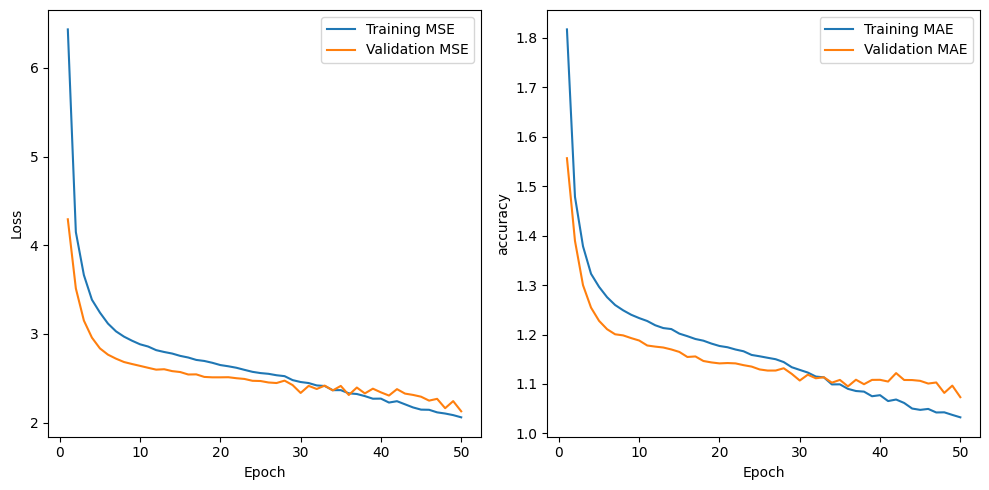

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)


# Plot training accuracy
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Training MSE')
plt.plot(epochs, val_losses, label='Validation MSE')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot training loss
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label='Training MAE')
plt.plot(epochs, val_accuracies, label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('accuracy')
plt.legend()

plt.tight_layout()
plt.show()
